In [110]:
import pandas as pd
import mygene
import networkx as nx
import re
from scipy import stats
from statsmodels.stats.multitest import multipletests
from scipy.stats import ttest_ind    # t-test for p-values
from scipy.stats import mannwhitneyu # Mann-Whitney U for p-values
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

### Step 1. Prune the gene list by removing all genes that do not have expression above 1 TPM in at least 3 samples.

In [87]:
tpm_filtered = pd.read_csv("GSE78220_norm_counts_TPM_GRCh38.p13_NCBI.tsv", sep="\t")

mask = (tpm_filtered.iloc[:, 1:] > 1).sum(axis=1) >= 3
# 1: bc the first column is gene names, so we start from index 1
# () > 1: check if TPM is greater than 1
# .sum(axis=1): count how many samples have TPM > 1 for each gene
# >= 3: keep genes that have TPM > 1 in at least 3 samples
# in the end, we get a boolean vector (mask) that indicates which genes pass the filter 
# column: e.g. TRUE TRUE FALSE TRUE ...

filtered_genes = tpm_filtered.loc[mask]
# keep the TRUE rows

print(filtered_genes.shape)
filtered_genes.head()

(20193, 29)


,GeneID,GSM2069823,GSM2069824,GSM2069825,GSM2069826,GSM2069827,GSM2069828,GSM2069829,GSM2069830,GSM2069831,...,GSM2069841,GSM2069842,GSM2069843,GSM2069844,GSM2069845,GSM2069846,GSM2069847,GSM2069848,GSM2069849,GSM2069850
1,653635,14.580,8.5530,16.6500,30.0400,13.6400,23.90,20.870,21.74,23.1100,...,20.0300,13.590,15.620,17.290,18.20,16.1000,27.240,16.99,15.080,24.970
2,102466751,9.791,3.9530,14.9500,6.8840,34.9600,23.60,22.380,16.45,17.9400,...,6.8280,8.803,22.600,12.510,33.23,9.0920,34.460,11.60,7.157,23.430
8,729737,1.238,0.8699,0.5833,0.9341,0.8281,1.98,1.709,3.09,0.9256,...,0.8779,2.277,3.012,7.225,2.13,0.6511,2.671,2.76,0.563,1.530
10,102723897,19.300,7.7200,15.9700,52.8200,17.0600,22.46,26.340,24.30,26.2900,...,21.4400,16.880,20.060,21.410,23.47,18.0900,34.040,24.44,16.470,25.250
11,102465909,5.786,2.8240,9.8690,3.7070,20.7400,10.59,10.780,11.31,8.1920,...,3.0730,3.827,9.453,6.254,13.48,3.7440,13.100,12.18,3.340,9.808


### Step 2. Next, obtain the network connecting only the genes that survived the filter in step 1. In thispruned network, compute the node degree (ND) and the betweenness centrality (BC) for all nodes that survived Step 1.

#### 2.1 Map GeneID (e.g. 7157) to gene symbol (e.g. TP53)

In [88]:
combined_score_threshold = 700
links = pd.read_csv("9606.protein.links.v12.0.txt", sep=" ")
links = links[links["combined_score"] > combined_score_threshold]


print(links.shape)
links.head()

(472000, 3)


,protein1,protein2,combined_score
85,9606.ENSP00000000233,9606.ENSP00000158762,825
130,9606.ENSP00000000233,9606.ENSP00000357048,718
160,9606.ENSP00000000233,9606.ENSP00000262305,952
197,9606.ENSP00000000233,9606.ENSP00000329419,752
268,9606.ENSP00000000233,9606.ENSP00000469035,795


In [89]:
entrez_ids = filtered_genes["GeneID"].tolist()
entrez_ids[:5]

[653635, 102466751, 729737, 102723897, 102465909]

In [90]:
mg = mygene.MyGeneInfo()  

results = mg.querymany(
    entrez_ids,
    scopes="entrezgene", # input IDs are 
    fields="symbol",     # return gene symbols
    species="human"
)

results[:5]


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
355 input query terms found no hit:	['100133331', '107984841', '107984847', '107984849', '107985733', '107985734', '105376725', '1053767


[{'query': '653635', '_id': '653635', '_score': 8.82, 'symbol': 'WASH7P'},
 {'query': '102466751',
  '_id': '102466751',
  '_score': 27.344273,
  'symbol': 'MIR6859-1'},
 {'query': '729737',
  '_id': '729737',
  '_score': 27.342747,
  'symbol': 'LOC729737'},
 {'query': '102723897',
  '_id': '102723897',
  '_score': 8.819866,
  'symbol': 'LOC102723897'},
 {'query': '102465909',
  '_id': '102465909',
  '_score': 27.342085,
  'symbol': 'MIR6859-2'}]

In [91]:
filtered_genes = filtered_genes.drop_duplicates(subset="GeneID")

mapping = {}

for r in results:
    if "symbol" in r:
        mapping[r["query"]] = r["symbol"]

list(mapping.items())[:10]

[('653635', 'WASH7P'),
 ('102466751', 'MIR6859-1'),
 ('729737', 'LOC729737'),
 ('102723897', 'LOC102723897'),
 ('102465909', 'MIR6859-2'),
 ('100132287', 'LOC100132287'),
 ('113219467', 'MIR12136'),
 ('100288069', 'LOC100288069'),
 ('79854', 'LINC00115'),
 ('643837', 'LINC01128')]

In [92]:
filtered_genes["symbol"] = filtered_genes["GeneID"].astype(str).map(mapping)

filtered_genes.head()

,GeneID,GSM2069823,GSM2069824,GSM2069825,GSM2069826,GSM2069827,GSM2069828,GSM2069829,GSM2069830,GSM2069831,...,GSM2069842,GSM2069843,GSM2069844,GSM2069845,GSM2069846,GSM2069847,GSM2069848,GSM2069849,GSM2069850,symbol
1,653635,14.580,8.5530,16.6500,30.0400,13.6400,23.90,20.870,21.74,23.1100,...,13.590,15.620,17.290,18.20,16.1000,27.240,16.99,15.080,24.970,WASH7P
2,102466751,9.791,3.9530,14.9500,6.8840,34.9600,23.60,22.380,16.45,17.9400,...,8.803,22.600,12.510,33.23,9.0920,34.460,11.60,7.157,23.430,MIR6859-1
8,729737,1.238,0.8699,0.5833,0.9341,0.8281,1.98,1.709,3.09,0.9256,...,2.277,3.012,7.225,2.13,0.6511,2.671,2.76,0.563,1.530,LOC729737
10,102723897,19.300,7.7200,15.9700,52.8200,17.0600,22.46,26.340,24.30,26.2900,...,16.880,20.060,21.410,23.47,18.0900,34.040,24.44,16.470,25.250,LOC102723897
11,102465909,5.786,2.8240,9.8690,3.7070,20.7400,10.59,10.780,11.31,8.1920,...,3.827,9.453,6.254,13.48,3.7440,13.100,12.18,3.340,9.808,MIR6859-2


#### 2.2 Prune the STRING network to keep only edges between your filtered genes

In [93]:
info = pd.read_csv("9606.protein.info.v12.0.txt", sep="\t")

# Keep only the columns we need & change column names 
info = info[["#string_protein_id", "preferred_name"]]

# rename for clarity
info.columns = ["string_id", "symbol"]    
filtered_genes.head()

,GeneID,GSM2069823,GSM2069824,GSM2069825,GSM2069826,GSM2069827,GSM2069828,GSM2069829,GSM2069830,GSM2069831,...,GSM2069842,GSM2069843,GSM2069844,GSM2069845,GSM2069846,GSM2069847,GSM2069848,GSM2069849,GSM2069850,symbol
1,653635,14.580,8.5530,16.6500,30.0400,13.6400,23.90,20.870,21.74,23.1100,...,13.590,15.620,17.290,18.20,16.1000,27.240,16.99,15.080,24.970,WASH7P
2,102466751,9.791,3.9530,14.9500,6.8840,34.9600,23.60,22.380,16.45,17.9400,...,8.803,22.600,12.510,33.23,9.0920,34.460,11.60,7.157,23.430,MIR6859-1
8,729737,1.238,0.8699,0.5833,0.9341,0.8281,1.98,1.709,3.09,0.9256,...,2.277,3.012,7.225,2.13,0.6511,2.671,2.76,0.563,1.530,LOC729737
10,102723897,19.300,7.7200,15.9700,52.8200,17.0600,22.46,26.340,24.30,26.2900,...,16.880,20.060,21.410,23.47,18.0900,34.040,24.44,16.470,25.250,LOC102723897
11,102465909,5.786,2.8240,9.8690,3.7070,20.7400,10.59,10.780,11.31,8.1920,...,3.827,9.453,6.254,13.48,3.7440,13.100,12.18,3.340,9.808,MIR6859-2


In [94]:
# Map your filtered genes to STRING IDs 
filtered_genes = filtered_genes.merge(info, on="symbol", how="inner")
# This uses the "symbol" column as the key to match rows in both data frames, i.e. info, filtered_genes.
 
filtered_genes.head()

,GeneID,GSM2069823,GSM2069824,GSM2069825,GSM2069826,GSM2069827,GSM2069828,GSM2069829,GSM2069830,GSM2069831,...,GSM2069843,GSM2069844,GSM2069845,GSM2069846,GSM2069847,GSM2069848,GSM2069849,GSM2069850,symbol,string_id
0,148398,8.7230,2.6880,1.67800,4.02800,1.8470,7.4030,7.80300,4.62900,11.2000,...,4.3280,9.341,4.098,28.360,45.940,15.3000,10.300,8.02800,SAMD11,9606.ENSP00000342313
1,26155,119.4000,28.7600,34.85000,74.85000,42.4000,51.4800,57.12000,49.73000,89.3300,...,46.7000,71.460,37.150,205.000,62.120,146.5000,72.340,47.71000,NOC2L,9606.ENSP00000317992
2,339451,9.3650,0.7969,1.37800,8.98900,1.5960,6.5960,1.58200,2.01900,22.8000,...,7.3520,4.650,5.896,5.804,23.310,5.7300,4.010,3.72000,KLHL17,9606.ENSP00000343930
3,84069,1.6020,1.0260,0.01016,0.08991,0.1266,0.3352,0.11260,0.27340,4.8550,...,1.3680,11.440,15.190,2.824,4.400,0.4925,1.304,0.23130,PLEKHN1,9606.ENSP00000368720
4,84808,0.2009,0.1593,0.02813,0.40840,0.2368,0.3442,0.03118,0.07734,0.8145,...,0.8427,2.804,29.160,1.479,1.141,0.4256,1.131,0.07175,PERM1,9606.ENSP00000414022


In [95]:
valid_string_ids = set(filtered_genes["string_id"])
print(f"Genes with STRING mapping: {len(valid_string_ids)}")

# Filter the STRING links to keep only edges between surviving genes
pruned_links = links[
    links["protein1"].isin(valid_string_ids) &
    links["protein2"].isin(valid_string_ids)
].copy()

print(f"Edges in pruned network: {len(pruned_links)}")
pruned_links.head()
# links columns are: protein1, protein2, combined_score

Genes with STRING mapping: 14591
Edges in pruned network: 379610


,protein1,protein2,combined_score
85,9606.ENSP00000000233,9606.ENSP00000158762,825
130,9606.ENSP00000000233,9606.ENSP00000357048,718
160,9606.ENSP00000000233,9606.ENSP00000262305,952
197,9606.ENSP00000000233,9606.ENSP00000329419,752
268,9606.ENSP00000000233,9606.ENSP00000469035,795


#### 2.3 Compute node degree (ND) and betweenness centrality (BC)

In [96]:
G = nx.from_pandas_edgelist(
    pruned_links,
    source="protein1",
    target="protein2",
    edge_attr="combined_score"
)

In [97]:
# wanted to see visualization - takes too long
# plt.figure(figsize=(10,10))
# nx.draw(G, with_labels=True, node_size=300, node_color="skyblue", font_size=8)
# plt.show()

In [98]:
# Add any surviving genes that have NO edges (isolated nodes)
G.add_nodes_from(valid_string_ids)

print(f"Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}")

# Compute Node Degree (ND)
nd = dict(G.degree())  # {string_id: degree}


Nodes: 14591, Edges: 189805


In [99]:
# Compute Betweenness Centrality (BC)
# bc = nx.betweenness_centrality(G, normalized=True)   # {string_id: bc_value}
# If too slow, use: 
bc = nx.betweenness_centrality(G, k=500, normalized=True)

In [100]:
# Attach ND and BC back to the filtered_genes dataframe  
filtered_genes["ND"] = filtered_genes["string_id"].map(nd)
filtered_genes["BC"] = filtered_genes["string_id"].map(bc)

# Nodes not in the graph get 0
filtered_genes["ND"] = filtered_genes["ND"].fillna(0)
filtered_genes["BC"] = filtered_genes["BC"].fillna(0)

filtered_genes.head()

,GeneID,GSM2069823,GSM2069824,GSM2069825,GSM2069826,GSM2069827,GSM2069828,GSM2069829,GSM2069830,GSM2069831,...,GSM2069845,GSM2069846,GSM2069847,GSM2069848,GSM2069849,GSM2069850,symbol,string_id,ND,BC
0,148398,8.7230,2.6880,1.67800,4.02800,1.8470,7.4030,7.80300,4.62900,11.2000,...,4.098,28.360,45.940,15.3000,10.300,8.02800,SAMD11,9606.ENSP00000342313,0,0.000000
1,26155,119.4000,28.7600,34.85000,74.85000,42.4000,51.4800,57.12000,49.73000,89.3300,...,37.150,205.000,62.120,146.5000,72.340,47.71000,NOC2L,9606.ENSP00000317992,186,0.000902
2,339451,9.3650,0.7969,1.37800,8.98900,1.5960,6.5960,1.58200,2.01900,22.8000,...,5.896,5.804,23.310,5.7300,4.010,3.72000,KLHL17,9606.ENSP00000343930,1,0.000000
3,84069,1.6020,1.0260,0.01016,0.08991,0.1266,0.3352,0.11260,0.27340,4.8550,...,15.190,2.824,4.400,0.4925,1.304,0.23130,PLEKHN1,9606.ENSP00000368720,0,0.000000
4,84808,0.2009,0.1593,0.02813,0.40840,0.2368,0.3442,0.03118,0.07734,0.8145,...,29.160,1.479,1.141,0.4256,1.131,0.07175,PERM1,9606.ENSP00000414022,1,0.000000


### Step 3. Compute the p-values and log2 FC for genes surviving Step 1. To this end, use the gene expression data in (normalized/raw) counts. Correct the significance of the p-values using Benjamini-Hochberg correction. Generate a volcano plot and perform a principal component analysis

Side note: 
- Fold Change (FC) measures how much a gene’s expression differs between two groups
$$
FC = \frac{\text{mean expression in group 2}}{\text{mean expression in group 1}}
$$

- P-value: probability that the observed difference happened by chance.
- Benjamini-Hochberg (BH) correction Adjusts p-values for multiple testing.
- Volcano plot = scatter plot of:

    - x-axis: log2 FC

    - y-axis: -log10(p-value)
- PCA: Uses gene expression to see if samples cluster by group (PD, PR, CR).

#### 3.1 From GSE78220_series_matrix extract response types (PD, PR, CR) and map them to GSM_ID.

3.1.1 Extract patient IDs and anti-PD-1 response 

In [101]:
file = "GSE78220_series_matrix.txt"

with open(file, "r") as f:
    lines = f.readlines()

# extract patient IDs and anti-PD-1 response from the !Sample_characteristics_ch1 line
char_lines = [line.strip() for line in lines if line.startswith("!Sample_characteristics_ch1")]
patient_line = char_lines[0].split("\t")[1:]   # skip header
response_line = char_lines[1].split("\t")[1:]  # skip header

# clean quotes and extract values
patients = [re.search(r"patient id: (.+?)$", x).group(1).replace('"','') for x in patient_line]
responses = [re.search(r"anti-pd-1 response: (.+?)$", x).group(1).replace('"','') for x in response_line]

# map patient ID to response
group_info = dict(zip(patients, responses))


3.1.2 Extract GSM IDs

In [ ]:
# Extract GSM IDs from !Sample_geo_accession line
gsm_line = [line.strip() for line in lines if line.startswith("!Sample_geo_accession")][0]
gsm_ids = gsm_line.split("\t")[1:]  # skip header
gsm_ids = [x.replace('"','') for x in gsm_ids]  # clean quotes

3.1.3 Map responses to GSM IDs 

In [103]:
# Map patient → GSM 
patient_to_gsm = dict(zip(patients, gsm_ids))

# Map GSM → response 
gsm_group_info = {patient_to_gsm[p]: r for p, r in zip(patients, responses)}

# Separate GSM IDs by response 
pd_gsm = [g for g in gsm_group_info if gsm_group_info[g] == "Progressive Disease"]
pr_gsm = [g for g in gsm_group_info if gsm_group_info[g] == "Partial Response"]
cr_gsm = [g for g in gsm_group_info if gsm_group_info[g] == "Complete Response"]

pd_gsm[:5], pr_gsm[:5], cr_gsm[:5]

# question: pr not needed?

(['GSM2069823', 'GSM2069828', 'GSM2069831', 'GSM2069832', 'GSM2069834'],
 ['GSM2069824', 'GSM2069825', 'GSM2069826', 'GSM2069827', 'GSM2069835'],
 ['GSM2069829', 'GSM2069830', 'GSM2069833', 'GSM2069843'])

#### 3.2 Calculate tests

Side note: 
- The null hypothesis is that the drugs are the same, and the p-value helps us decide if we should reject the null hypothesis or not.

3.2.1 P-values, log2fc

In [ ]:
# Load raw counts
counts = pd.read_csv("GSE78220_raw_counts_GRCh38.p13_NCBI.tsv", sep="\t")

# Keep only genes that survived Step 1 
counts = counts[counts["GeneID"].isin(filtered_genes["GeneID"])]
counts = counts.set_index("GeneID") 

# Identify which columns belong to PD and CR
pd_cols = [c for c in counts.columns if c in pd_gsm]
cr_cols = [c for c in counts.columns if c in cr_gsm]

print(f"PD samples: {len(pd_cols)}, CR samples: {len(cr_cols)}")

PD samples: 13, CR samples: 4


In [ ]:
pvals = []
log2fc = []

for gene in counts.index:
    pd_expr = counts.loc[gene, pd_cols].values.astype(float)
    cr_expr = counts.loc[gene, cr_cols].values.astype(float)
    
    # log2 FC: CR vs PD (positive = higher in CR)
    mean_pd = np.mean(pd_expr)
    mean_cr = np.mean(cr_expr)
    # add pseudocount to avoid log(0)
    fc = np.log2((mean_cr + 1) / (mean_pd + 1))
    log2fc.append(fc)
    
    # Mann-Whitney U test (non-parametric, good for small n)
    try:
        _, p = mannwhitneyu(cr_expr, pd_expr, alternative="two-sided")
    except ValueError:
        p = 1.0
    pvals.append(p)

In [113]:
log2fc[:5], pvals[:5]   

([np.float64(-1.302144985519907),
  np.float64(-0.6183681837247512),
  np.float64(-1.0033850926239969),
  np.float64(-1.2989217799494421),
  np.float64(-2.8764620338219773)],
 [np.float64(0.10168067226890756),
  np.float64(0.35042016806722687),
  np.float64(0.16302521008403362),
  np.float64(0.35042016806722687),
  np.float64(0.24537815126050422)])

3.2.2 BH correction

In [114]:
reject, pvals_adj, _, _ = multipletests(pvals, method="fdr_bh")

# Attach to filtered_genes
stat_df = pd.DataFrame({
    "GeneID": counts.index,
    "log2FC": log2fc,
    "pval": pvals,
    "pval_adj": pvals_adj
}).reset_index(drop=True)

# GeneID may be int in filtered_genes — match types
stat_df["GeneID"] = stat_df["GeneID"].astype(str)
filtered_genes["GeneID"] = filtered_genes["GeneID"].astype(str)

filtered_genes = filtered_genes.merge(stat_df, on="GeneID", how="left")
filtered_genes.head()

,GeneID,GSM2069823,GSM2069824,GSM2069825,GSM2069826,GSM2069827,GSM2069828,GSM2069829,GSM2069830,GSM2069831,...,GSM2069848,GSM2069849,GSM2069850,symbol,string_id,ND,BC,log2FC,pval,pval_adj
0,148398,8.7230,2.6880,1.67800,4.02800,1.8470,7.4030,7.80300,4.62900,11.2000,...,15.3000,10.300,8.02800,SAMD11,9606.ENSP00000342313,0,0.000000,-1.302145,0.101681,1.0
1,26155,119.4000,28.7600,34.85000,74.85000,42.4000,51.4800,57.12000,49.73000,89.3300,...,146.5000,72.340,47.71000,NOC2L,9606.ENSP00000317992,186,0.000902,-0.618368,0.350420,1.0
2,339451,9.3650,0.7969,1.37800,8.98900,1.5960,6.5960,1.58200,2.01900,22.8000,...,5.7300,4.010,3.72000,KLHL17,9606.ENSP00000343930,1,0.000000,-1.003385,0.163025,1.0
3,84069,1.6020,1.0260,0.01016,0.08991,0.1266,0.3352,0.11260,0.27340,4.8550,...,0.4925,1.304,0.23130,PLEKHN1,9606.ENSP00000368720,0,0.000000,-1.298922,0.350420,1.0
4,84808,0.2009,0.1593,0.02813,0.40840,0.2368,0.3442,0.03118,0.07734,0.8145,...,0.4256,1.131,0.07175,PERM1,9606.ENSP00000414022,1,0.000000,-2.876462,0.245378,1.0


3.2.3 Volcano plot

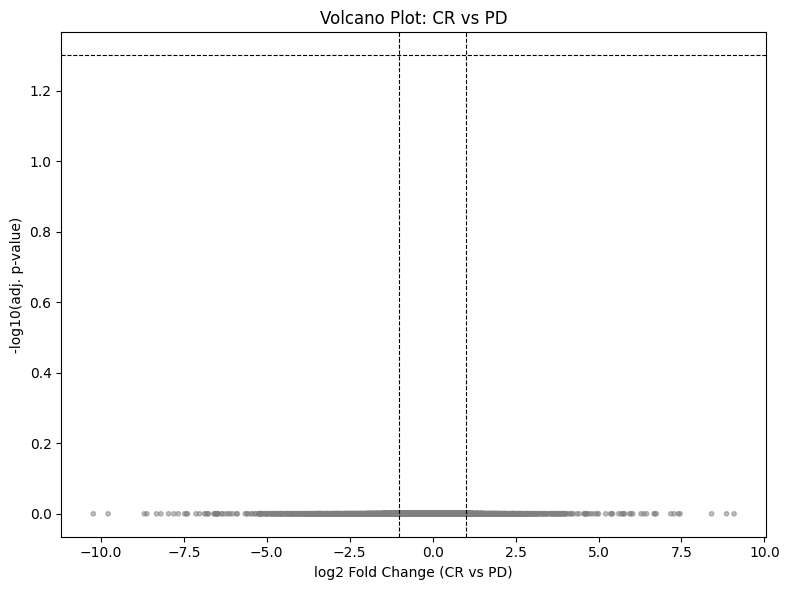

In [116]:
fig, ax = plt.subplots(figsize=(8, 6))

neg_log10_p = -np.log10(filtered_genes["pval_adj"] + 1e-300)

# Color by significance and fold change
colors = []
for fc, p in zip(filtered_genes["log2FC"], filtered_genes["pval_adj"]):
    if p < 0.05 and fc > 1:
        colors.append("red")       # up in CR
    elif p < 0.05 and fc < -1:
        colors.append("blue")      # up in PD
    else:
        colors.append("grey")

ax.scatter(filtered_genes["log2FC"], neg_log10_p, c=colors, alpha=0.5, s=10)
ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8)
ax.axvline(1, color="black", linestyle="--", linewidth=0.8)
ax.axvline(-1, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("log2 Fold Change (CR vs PD)")
ax.set_ylabel("-log10(adj. p-value)")
ax.set_title("Volcano Plot: CR vs PD")
plt.tight_layout()
plt.show()

3.2.4 PCA

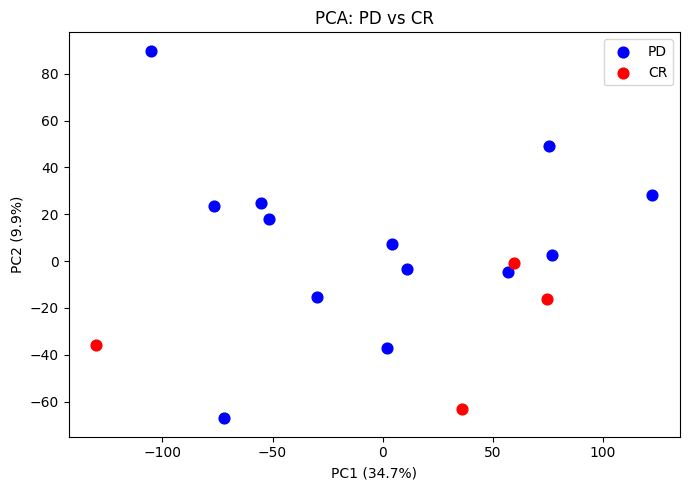

In [115]:
# Use PD + CR samples only, genes that survived step 1
pca_cols = pd_cols + cr_cols
pca_data = counts[pca_cols].T  # shape: (samples, genes)

# Log-transform + scale
pca_data_log = np.log2(pca_data + 1)
scaler = StandardScaler()
pca_scaled = scaler.fit_transform(pca_data_log)

pca = PCA(n_components=2)
components = pca.fit_transform(pca_scaled)

# Labels
labels = ["PD"] * len(pd_cols) + ["CR"] * len(cr_cols)
label_colors = {"PD": "blue", "CR": "red"}

fig, ax = plt.subplots(figsize=(7, 5))
for label in ["PD", "CR"]:
    idx = [i for i, l in enumerate(labels) if l == label]
    ax.scatter(components[idx, 0], components[idx, 1],
               label=label, color=label_colors[label], s=60)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA: PD vs CR")
ax.legend()
plt.tight_layout()
plt.show()